<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-07-20 23:23:05--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  43.4MB/s    in 3.9s    

2026-07-20 23:23:10 (38.8 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



In [4]:
##Write your code here
df_plot = (
    df[["DatabaseWantToWorkWith"]]
    .dropna()
    .copy()
)

df_plot["DatabaseWantToWorkWith"] = (
    df_plot["DatabaseWantToWorkWith"]
    .str.split(";")
)

df_plot = df_plot.explode("DatabaseWantToWorkWith")

df_plot["DatabaseWantToWorkWith"] = (
    df_plot["DatabaseWantToWorkWith"]
    .str.strip()
)

top_databases = (
    df_plot["DatabaseWantToWorkWith"]
    .value_counts()
    .head(5)
)

print(top_databases)

DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64


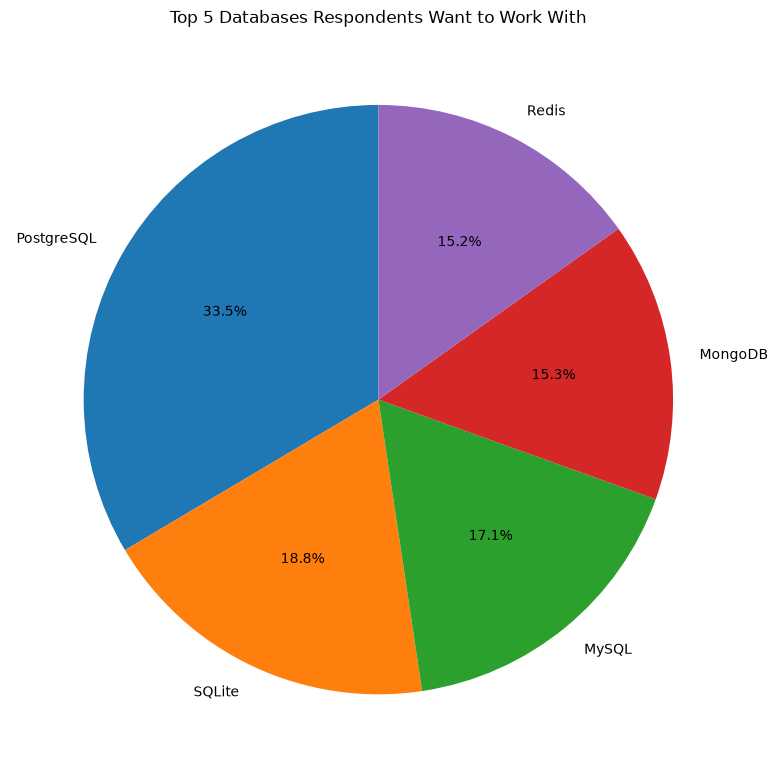

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    top_databases.values,
    labels=top_databases.index,
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title("Top 5 Databases Respondents Want to Work With")

plt.tight_layout()
plt.show()

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



In [6]:
##Write your code here
df_plot = (
    df[["DevType"]]
    .dropna()
    .copy()
)

df_plot["DevType"] = (
    df_plot["DevType"]
    .str.split(";")
)

df_plot = df_plot.explode("DevType")

df_plot["DevType"] = (
    df_plot["DevType"]
    .str.strip()
)

top_dev_roles = (
    df_plot["DevType"]
    .value_counts()
    .head(5)
)

print(top_dev_roles)

DevType
Developer, full-stack                            18260
Developer, back-end                               9928
Student                                           5102
Developer, front-end                              3349
Developer, desktop or enterprise applications     2493
Name: count, dtype: int64


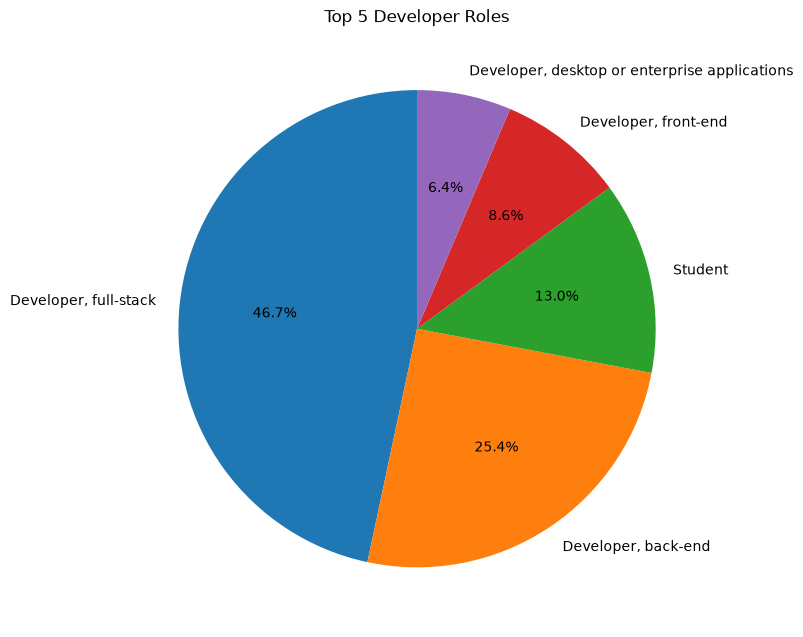

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    top_dev_roles.values,
    labels=top_dev_roles.index,
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title("Top 5 Developer Roles")

plt.tight_layout()
plt.show()

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



In [8]:
##Write your code here
df_plot = (
    df[["OpSysProfessional use"]]
    .dropna()
    .copy()
)

df_plot["OpSysProfessional use"] = (
    df_plot["OpSysProfessional use"]
    .str.split(";")
)

df_plot = df_plot.explode("OpSysProfessional use")

df_plot["OpSysProfessional use"] = (
    df_plot["OpSysProfessional use"]
    .str.strip()
)

top_operating_systems = (
    df_plot["OpSysProfessional use"]
    .value_counts()
    .head(5)
)

print(top_operating_systems)

OpSysProfessional use
Windows                              27918
MacOS                                18625
Ubuntu                               16237
Windows Subsystem for Linux (WSL)     9859
Debian                                5327
Name: count, dtype: int64


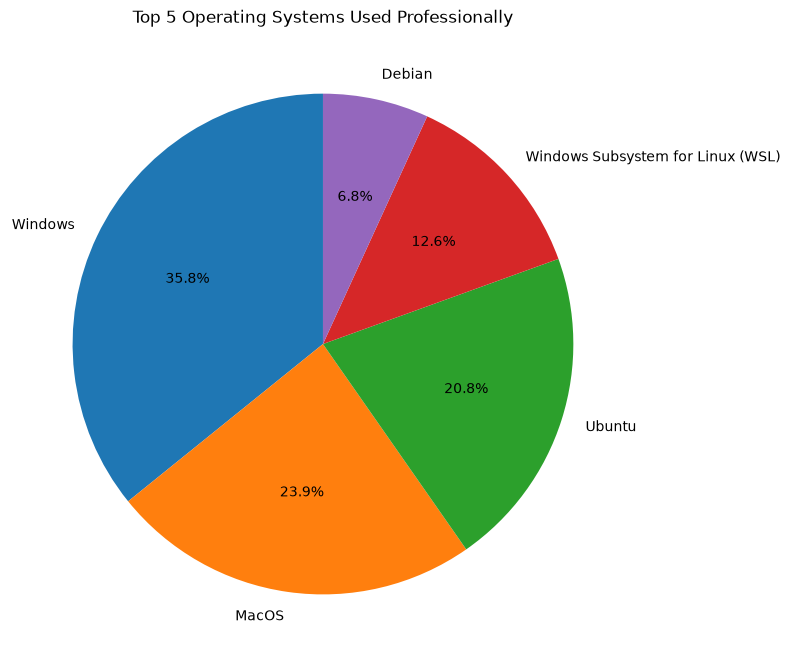

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    top_operating_systems.values,
    labels=top_operating_systems.index,
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title("Top 5 Operating Systems Used Professionally")

plt.tight_layout()
plt.show()

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



In [10]:
##Write your code here
df_plot = (
    df[["LanguageHaveWorkedWith"]]
    .dropna()
    .copy()
)

df_plot["LanguageHaveWorkedWith"] = (
    df_plot["LanguageHaveWorkedWith"]
    .str.split(";")
)

df_plot = df_plot.explode("LanguageHaveWorkedWith")

df_plot["LanguageHaveWorkedWith"] = (
    df_plot["LanguageHaveWorkedWith"]
    .str.strip()
)

df_plot = df_plot[
    df_plot["LanguageHaveWorkedWith"].ne("")
].copy()

top_languages = (
    df_plot["LanguageHaveWorkedWith"]
    .value_counts()
    .head(5)
)

print(top_languages)

LanguageHaveWorkedWith
JavaScript    37492
HTML/CSS      31816
Python        30719
SQL           30682
TypeScript    23150
Name: count, dtype: int64


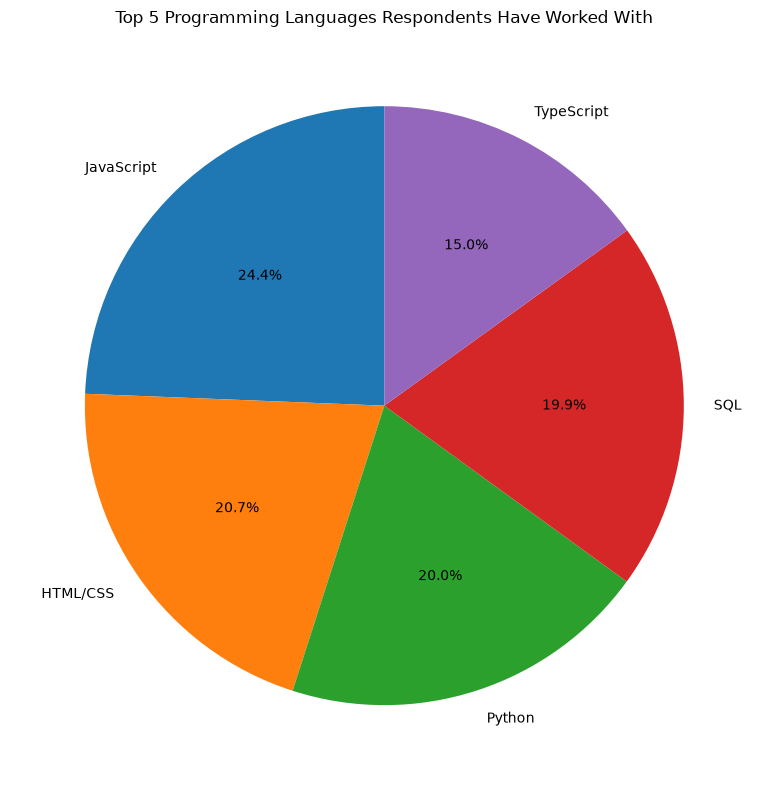

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    top_languages.values,
    labels=top_languages.index,
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title(
    "Top 5 Programming Languages Respondents Have Worked With"
)

plt.tight_layout()
plt.show()

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



In [13]:
##Write your code here
df_plot = (
    df[["NEWCollabToolsHaveWorkedWith"]]
    .dropna()
    .copy()
)

df_plot["NEWCollabToolsHaveWorkedWith"] = (
    df_plot["NEWCollabToolsHaveWorkedWith"]
    .str.split(";")
)

df_plot = df_plot.explode("NEWCollabToolsHaveWorkedWith")

df_plot["NEWCollabToolsHaveWorkedWith"] = (
    df_plot["NEWCollabToolsHaveWorkedWith"]
    .str.strip()
)

df_plot = df_plot[
    df_plot["NEWCollabToolsHaveWorkedWith"].ne("")
].copy()

top_collab_tools = (
    df_plot["NEWCollabToolsHaveWorkedWith"]
    .value_counts()
    .head(5)
)

print(top_collab_tools)

NEWCollabToolsHaveWorkedWith
Visual Studio Code    42751
Visual Studio         17021
IntelliJ IDEA         15555
Notepad++             13874
Vim                   12523
Name: count, dtype: int64


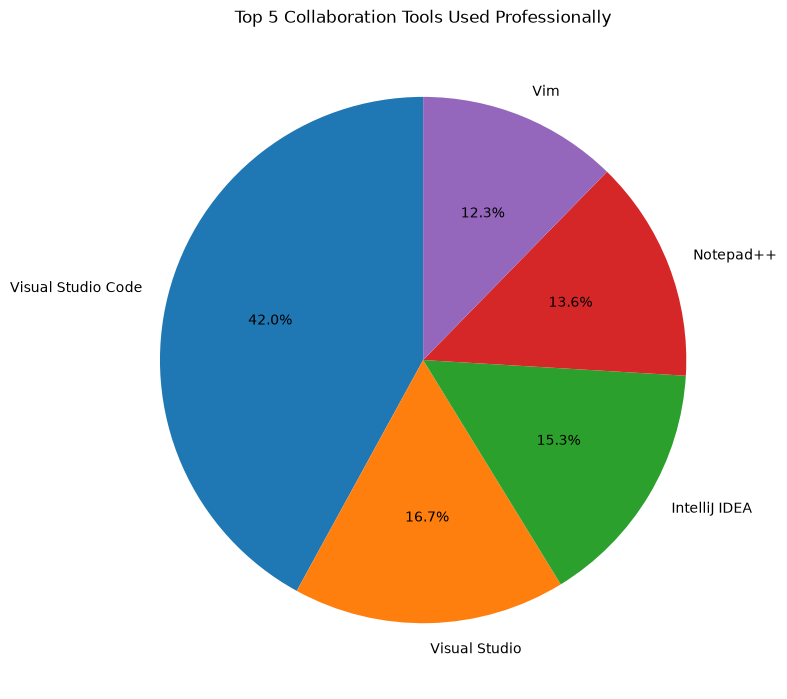

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    top_collab_tools.values,
    labels=top_collab_tools.index,
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title(
    "Top 5 Collaboration Tools Used Professionally"
)

plt.tight_layout()
plt.show()

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



In [15]:
##Write your code here
df_plot = (
    df[["LanguageAdmired"]]
    .dropna()
    .copy()
)

df_plot["LanguageAdmired"] = (
    df_plot["LanguageAdmired"]
    .str.split(";")
)

df_plot = df_plot.explode("LanguageAdmired")

df_plot["LanguageAdmired"] = (
    df_plot["LanguageAdmired"]
    .str.strip()
)

df_plot = df_plot[
    df_plot["LanguageAdmired"].ne("")
].copy()

top_admired_languages = (
    df_plot["LanguageAdmired"]
    .value_counts()
    .head(5)
)

print(top_admired_languages)

LanguageAdmired
JavaScript    21869
Python        20774
SQL           20692
HTML/CSS      19851
TypeScript    16079
Name: count, dtype: int64


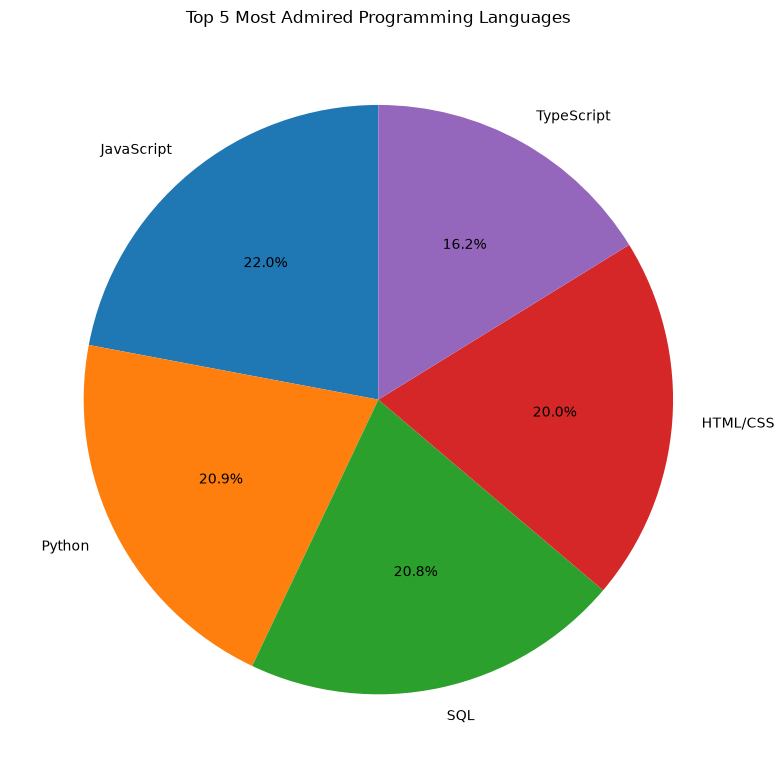

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    top_admired_languages.values,
    labels=top_admired_languages.index,
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title(
    "Top 5 Most Admired Programming Languages"
)

plt.tight_layout()
plt.show()

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



In [17]:
##Write your code here

ai_tool_column = "AIToolCurrently Using"

df_plot = (
    df[[ai_tool_column]]
    .dropna()
    .copy()
)

df_plot[ai_tool_column] = (
    df_plot[ai_tool_column]
    .str.split(";")
)

df_plot = df_plot.explode(ai_tool_column)

df_plot[ai_tool_column] = (
    df_plot[ai_tool_column]
    .str.strip()
)

df_plot = df_plot[
    df_plot[ai_tool_column].ne("")
].copy()

top_ai_tools = (
    df_plot[ai_tool_column]
    .value_counts()
    .head(5)
)

print(top_ai_tools)

AIToolCurrently Using
Writing code                            29486
Search for answers                      24295
Debugging and getting help              20404
Documenting code                        14439
Generating content or synthetic data    12538
Name: count, dtype: int64


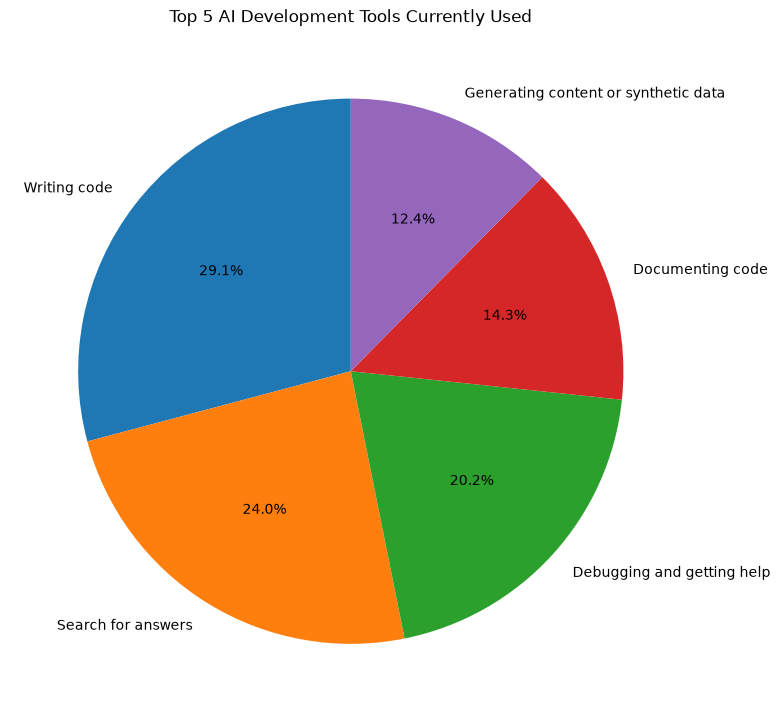

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    top_ai_tools.values,
    labels=top_ai_tools.index,
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title(
    "Top 5 AI Development Tools Currently Used"
)

plt.tight_layout()
plt.show()

##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



In [19]:
##Write your code here
df_plot = (
    df[["WebframeWantToWorkWith"]]
    .dropna()
    .copy()
)

df_plot["WebframeWantToWorkWith"] = (
    df_plot["WebframeWantToWorkWith"]
    .str.split(";")
)

df_plot = df_plot.explode("WebframeWantToWorkWith")

df_plot["WebframeWantToWorkWith"] = (
    df_plot["WebframeWantToWorkWith"]
    .str.strip()
)

df_plot = df_plot[
    df_plot["WebframeWantToWorkWith"].ne("")
].copy()

top_web_frameworks = (
    df_plot["WebframeWantToWorkWith"]
    .value_counts()
    .head(5)
)

print(top_web_frameworks)

WebframeWantToWorkWith
React           15404
Node.js         14735
Next.js          8507
Vue.js           7604
ASP.NET CORE     6905
Name: count, dtype: int64


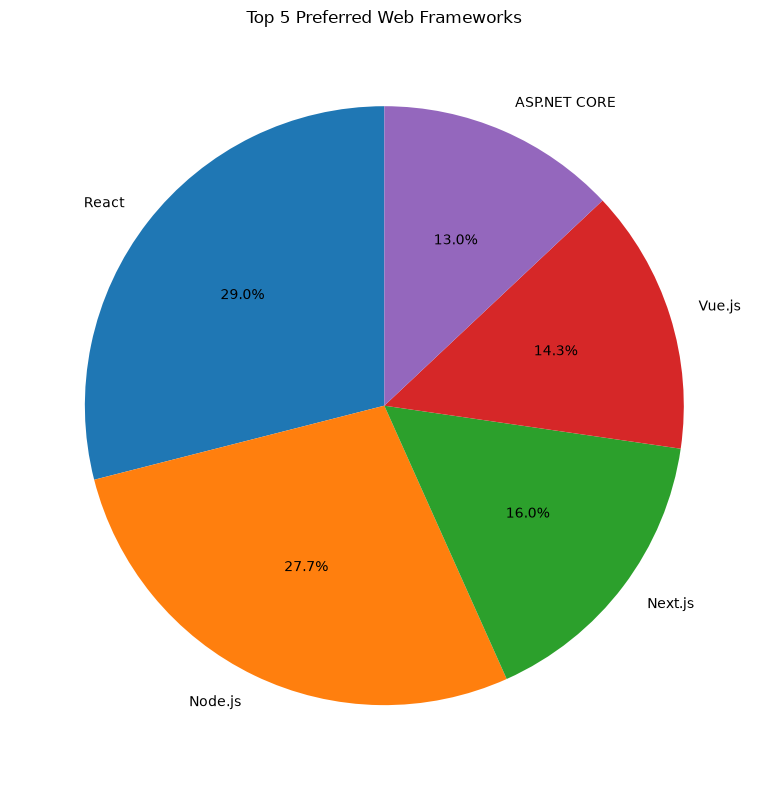

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    top_web_frameworks.values,
    labels=top_web_frameworks.index,
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title(
    "Top 5 Preferred Web Frameworks"
)

plt.tight_layout()
plt.show()

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



In [21]:
##Write your code here
df_plot = (
    df[["EmbeddedWantToWorkWith"]]
    .dropna()
    .copy()
)

df_plot["EmbeddedWantToWorkWith"] = (
    df_plot["EmbeddedWantToWorkWith"]
    .str.split(";")
)

df_plot = df_plot.explode("EmbeddedWantToWorkWith")

df_plot["EmbeddedWantToWorkWith"] = (
    df_plot["EmbeddedWantToWorkWith"]
    .str.strip()
)

df_plot = df_plot[
    df_plot["EmbeddedWantToWorkWith"].ne("")
].copy()

top_embedded_technologies = (
    df_plot["EmbeddedWantToWorkWith"]
    .value_counts()
    .head(5)
)

print(top_embedded_technologies)


EmbeddedWantToWorkWith
Rasberry Pi    9792
Arduino        6482
GNU GCC        5870
CMake          4693
Cargo          4567
Name: count, dtype: int64


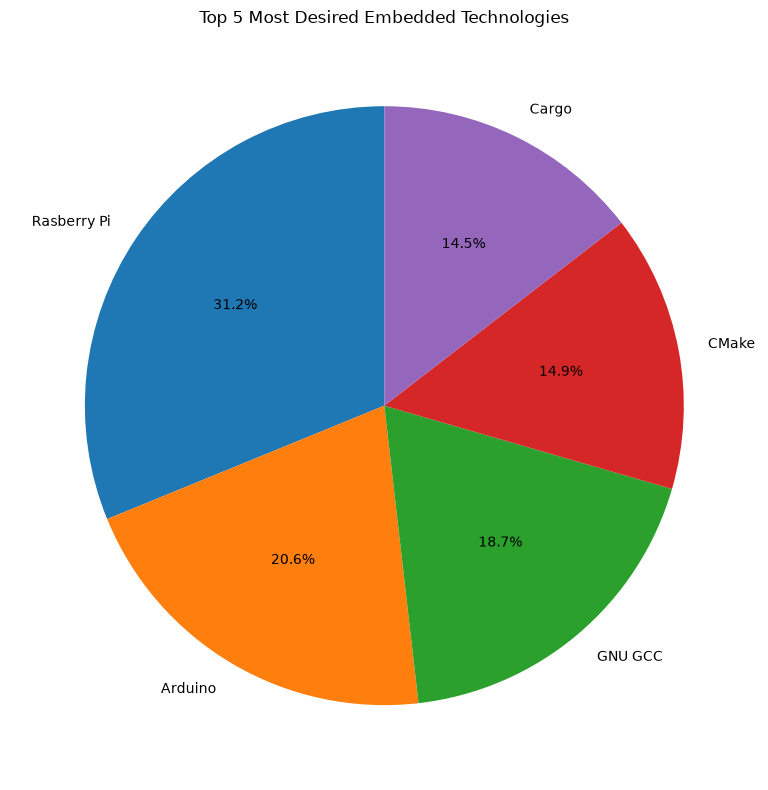

In [23]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    top_embedded_technologies.values,
    labels=top_embedded_technologies.index,
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title(
    "Top 5 Most Desired Embedded Technologies"
)

plt.tight_layout()
plt.show()

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
